# Welcome to meme generation notebook! 🤠

The goal is to have fun. However, there are prerequisites that would make it possible:



*   You should have a Hugging Face token that we will use for Inference API.
*   You should mount your drive to provide access to the folder "meme_caption_generation".
*   This is done to get the meme font (Anton), as well as for getting access to other data.







Specify your Hugging Face token

In [ ]:
import random
import re

In [ ]:
hf_token = "hf_YOUR_TOKEN"

Mount content from your drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Preparation: install libraries, load the model

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
from torch import __version__; from packaging.version import Version as V
xformers = "xformers==0.0.27" if V(__version__) < V("2.4.0") else "xformers"
!pip install --no-deps {xformers} trl peft accelerate bitsandbytes triton

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-7swmj4u7/unsloth_6e64514efef847f3aa5ca20a734b2f21
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-7swmj4u7/unsloth_6e64514efef847f3aa5ca20a734b2f21
  Resolved https://github.com/unslothai/unsloth.git to commit 62c989ef0ae0e9fbac714a4cb21eda76c1fe84b6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.3/474.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 11.9 MB/s eta 0:00:00
   ━

In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 128 #
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
==((====))==  Unsloth 2024.9: Fast Llama patching. Transformers = 4.44.2.
   \\   /|    GPU: Tesla T4. Max memory: 14.748 GB. Platform = Linux.
O^O/ \_/ \    Pytorch: 2.4.0+cu121. CUDA = 7.5. CUDA Toolkit = 12.1.
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.28.post1. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

## Creating examples for different sentiments


We will create funny meme captions for different sentiments and pass it as an example to the model. We unify the format of memes to make the output more predictable - at the end of the day, we all know the instruction-tuned models are often very chatty and even if you ask them to produce a caption only, they will still say: **"Certainly! I'm happy to provide you with one caption only..."**

In [ ]:
all_prompts = dict()

In [ ]:
# anger, disgust, fear, happiness, sadness and surprise

In [ ]:
all_prompts['happy'] = {}
all_prompts['happy']['examples'] = ["Caption: 'POV: he noticed my new haircut', Emotion: happy",
    "Caption: 'POV: you find $5 in your coat pocket from last winter', Emotion: happy",
    "Caption: 'POV: my feet when I wear a fresh pair of socks', Emotion: happy",
    "Caption: 'POV: Trump imposing new sanctions', Emotion: happy",
    "Caption: 'POV: average politics enjoyer', Emotion: happy",
    "Caption: 'POV: me when I learned I have tatar blood', Emotion: happy",
    "Caption: 'POV: me when I hear about planned economy', Emotion: happy",
    "Caption: 'POV: me when I finally scratched that spot', Emotion: happy",
    "Caption: 'POV: me when the cashier said 'Hello' back', Emotion: happy",
    "Caption: 'POV: me and my homies after we all got the same weekend off', Emotion: happy"]

all_prompts['happy']['prompt'] = "Generate a short meme caption that will accompany some happy image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['evil'] = {}
all_prompts['evil']['examples'] = ["Caption: 'POV: me when a random person on the street slips on ice', Emotion: evil",
                                   "Caption: 'POV: when you read a message but didn’t reply.', Emotion: evil",
                                   "Caption: 'POV: when you finish the milk and put the empty carton back in the freezer', Emotion: evil",
                                   "Caption: 'POV: when you said you don't have an extra chewing gum', Emotion: evil",
                                   "Caption: 'POV: you used 4 spaces instead of tab', Emotion: evil",
                                   "Caption: 'POV: your mom saying that nothing happens if you only tell the truth, Emotion: evil",
                                   "Caption: 'POV: the teacher saying that the exam will be easier than classes', Emotion: evil",
                                   "Caption: 'POV: me saying 'croissant' with an accent next to a French person', Emotion: evil",
                                   "Caption: 'POV: God inventing wasps', Emotion: evil"]

all_prompts['evil']['prompt'] = "Generate a short meme caption that will accompany some evil image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['sad'] = {}
all_prompts['sad']['examples'] = ["Caption: 'POV: You’ve been waiting 5 minutes for your food delivery', Emotion: sad",
    "Caption: 'POV: Your favorite TV show just ended and now you have no purpose in life', Emotion: sad",
    "Caption: 'POV: You’re trying to sleep, but suddenly remember that embarrassing thing you did 5 years ago', Emotion: sad",
    "Caption: 'POV: Your favorite snack expired yesterday', Emotion: sad",
    "Caption: 'POV: This feeling when someone ate my snack', Emotion: sad",
    "Caption: 'POV: When you accidentally drop a fry between the car seats', Emotion: sad",
    "Caption: 'POV: When you step out of the shower and realize you forgot a towel', Emotion: sad",
    "Caption: 'POV: The plant you forgot to water:', Emotion: sad",
    "Caption: 'POV: My eyes when it's raining:', Emotion: sad",
    "Caption: 'POV: Me when no one texted me for 10 minutes:', Emotion: sad"
               ]

all_prompts['sad']['prompt'] = "Generate a short meme caption that will accompany some sad image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['angry'] = {}
all_prompts['angry']['examples'] = ["Caption: 'Me when my shoe laces untied again', Emotion: angry",

    "Caption: 'Nobody: \nAverage finance bros after long day:', Emotion: angry",
    "Caption: 'Nobody: \nEuropean countries when they haven't colonized anyone for more than a decade:', Emotion: angry",
    "Caption: 'Me when they don't understand the difference between Hegel and Kant:', Emotion: angry",
    "Caption: 'Me when I get criticized for a thing I did wrong:', Emotion: angry",
    "Caption: 'Me when I learn my friends have other friends:', Emotion: angry",
    "Caption: 'My mom when I didn't wash the dishes immediately:', Emotion: angry",
    "Caption: 'Nobody: \nPeople when they learn I wear sandals with socks:', Emotion: angry",
    "Caption: 'Nobody: \nMy cat when I don't pet her:', Emotion: angry",
    "Caption: 'POV: \nDuolingo when you missed your Spanish lesson:', Emotion: angry"
               ]

all_prompts['angry']['prompt'] = "Generate a short meme caption that will accompany some angry image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['puzzled'] = {}
all_prompts['puzzled']['examples'] = ["Caption: 'Me when my shoe laces untied again', Emotion: puzzled",

    "Caption: 'Nobody: \nAverage finance bros after long day:', Emotion: puzzled",
    "Caption: 'Nobody: \nEuropean countries when they haven't colonized anyone for more than a decade:', Emotion: puzzled",
    "Caption: 'Me when they don't understand the difference between Hegel and Kant:', Emotion: puzzled",
    "Caption: 'Me when I get criticized for a thing I did wrong:', Emotion: puzzled",
    "Caption: 'Me when I learn my friends have other friends:', Emotion: puzzled",
    "Caption: 'My mom when I didn't wash the dishes immediately:', Emotion: puzzled",
    "Caption: 'Nobody: \nPeople when they learn I wear sandals with socks:', Emotion: puzzled",
    "Caption: 'Nobody: \nMy cat when I don't pet her:', Emotion: puzzled",
    "Caption: 'POV: \nDuolingo when you missed your Spanish lesson:', Emotion: puzzled"
               ]

all_prompts['puzzled']['prompt'] = "Generate a short meme caption that will accompany some puzzled image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['sexy'] = {}
all_prompts['sexy']['examples'] = ["Caption: 'POV: When you bought new clothes and showing off to your mom', Emotion: sexy",
    "Caption: 'POV: When you got one swipe on Tinder', Emotion: sexy",
    "Caption: 'POV: \nYou’re trying to sleep, but suddenly remember that embarrassing thing you did 5 years ago', Emotion: sexy",
    "Caption: 'POV: \nYour favorite snack expired yesterday', Emotion: sexy",
    "Caption: 'This feeling when \nsomeone ate my snack', Emotion: sexy",
    "Caption: 'When you accidentally drop a fry between the car seats', Emotion: sexy",
    "Caption: 'When you step out of the shower and realize you forgot a towel', Emotion: sexy",
    "Caption: 'Nobody: \nThe plant you forgot to water:', Emotion: sexy",
    "Caption: 'Nobody: \nMy eyes when it's raining:', Emotion: sexy",
    "Caption: 'Me when no one texted me for 10 minutes:', Emotion: sexy"
               ]

all_prompts['sexy']['prompt'] = "Generate a short meme caption that will accompany some sexy image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['fear'] = {}
all_prompts['fear']['examples'] = ["Caption: 'POV: You’ve been waiting 5 minutes for your food delivery', Emotion: fear",
    "Caption: 'POV: Your favorite TV show just ended and now you have no purpose in life', Emotion: fear",
    "Caption: 'POV: You’re trying to sleep, but suddenly remember that embarrassing thing you did 5 years ago', Emotion: fear",
    "Caption: 'POV: Your favorite snack expired yesterday', Emotion: fear",
    "Caption: 'This feeling when someone ate my snack', Emotion: fear",
    "Caption: 'When you accidentally drop a fry between the car seats', Emotion: fear",
    "Caption: 'When you step out of the shower and realize you forgot a towel', Emotion: fear",
    "Caption: 'Nobody: The plant you forgot to water:', Emotion: fear",
    "Caption: 'Nobody: My eyes when it's raining:', Emotion: fear",
    "Caption: 'Me when no one texted me for 10 minutes:', Emotion: fear"
               ]

all_prompts['fear']['prompt'] = "Generate a short meme caption that will accompany some frightened image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['cool'] = {}
all_prompts['cool']['examples'] = ["Caption: 'POV: \nYou’ve been waiting 5 minutes for your food delivery', Emotion: cool",
    "Caption: 'POV: \nYour favorite TV show just ended and now you have no purpose in life', Emotion: cool",
    "Caption: 'POV: \nYou’re trying to sleep, but suddenly remember that embarrassing thing you did 5 years ago', Emotion: cool",
    "Caption: 'POV: \nYour favorite snack expired yesterday', Emotion: cool",
    "Caption: 'This feeling when \nsomeone ate my snack', Emotion: cool",
    "Caption: 'When you accidentally drop a fry between the car seats', Emotion: cool",
    "Caption: 'When you step out of the shower and realize you forgot a towel', Emotion: cool",
    "Caption: 'Nobody: \nThe plant you forgot to water:', Emotion: cool",
    "Caption: 'Nobody: \nMy eyes when it's raining:', Emotion: cool",
    "Caption: 'Me when no one texted me for 10 minutes:', Emotion: cool"
               ]

all_prompts['cool']['prompt'] = "Generate a short meme caption that will accompany some cool image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['disgust'] = {}
all_prompts['disgust']['examples'] = ["Caption: 'POV: \nYou’ve been waiting 5 minutes for your food delivery', Emotion: disgust",
    "Caption: 'POV: \nYour favorite TV show just ended and now you have no purpose in life', Emotion: disgust",
    "Caption: 'POV: \nYou’re trying to sleep, but suddenly remember that embarrassing thing you did 5 years ago', Emotion: disgust",
    "Caption: 'POV: \nYour favorite snack expired yesterday', Emotion: disgust",
    "Caption: 'This feeling when \nsomeone ate my snack', Emotion: disgust",
    "Caption: 'When you accidentally drop a fry between the car seats', Emotion: disgust",
    "Caption: 'When you step out of the shower and realize you forgot a towel', Emotion: disgust",
    "Caption: 'Nobody: \nThe plant you forgot to water:', Emotion: disgust",
    "Caption: 'Nobody: \nMy eyes when it's raining:', Emotion: disgust",
    "Caption: 'Me when no one texted me for 10 minutes:', Emotion: disgust"
               ]

all_prompts['disgust']['prompt'] = "Generate a short meme caption that will accompany some disgusted image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
all_prompts['other'] = {}
all_prompts['other']['examples'] = ["Caption: 'POV: \nYou’ve been waiting 5 minutes for your food delivery', Emotion: other",
    "Caption: 'POV: \nYour favorite TV show just ended and now you have no purpose in life', Emotion: other",
    "Caption: 'POV: \nYou’re trying to sleep, but suddenly remember that embarrassing thing you did 5 years ago', Emotion: other",
    "Caption: 'POV: \nYour favorite snack expired yesterday', Emotion: other",
    "Caption: 'This feeling when \nsomeone ate my snack', Emotion: other",
    "Caption: 'When you accidentally drop a fry between the car seats', Emotion: other",
    "Caption: 'When you step out of the shower and realize you forgot a towel', Emotion: other",
    "Caption: 'Nobody: \nThe plant you forgot to water:', Emotion: other",
    "Caption: 'Nobody: \nMy eyes when it's raining:', Emotion: other",
    "Caption: 'Me when no one texted me for 10 minutes:', Emotion: other"
               ]

all_prompts['other']['prompt'] = "Generate a short meme caption that will accompany some other image. Only generate one-sentence meme caption and nothing else. Don't repeat the examples, generate new meme caption!"

In [ ]:
for mood in all_prompts:
  random.shuffle(all_prompts[mood]['examples'])

In [ ]:
len(all_prompts)

10

## Load CLIP model

We will use the CLIP model to extract the sentiment of the image.

In [ ]:
import base64
import requests
import json
import pandas as pd
import os
from tqdm import tqdm

Load your Hugging Face token for using InferenceAPI.

In [ ]:
API_URL = "https://api-inference.huggingface.co/models/openai/clip-vit-base-patch32"
headers = {"Authorization": f"Bearer {hf_token}"}

In [ ]:
def query(data):
	'''
	A function to query CLIP model
	'''
	with open(data["image_path"], "rb") as f:
		img = f.read()
	payload={
		"parameters": data["parameters"],
		"inputs": base64.b64encode(img).decode("utf-8")
	}
	response = requests.post(API_URL, headers=headers, json=payload)
	return response.json()

In [ ]:
def get_sentiment(img_path):
    output = query({
      "image_path": img_path,
      "parameters": {"candidate_labels": ["sad", "angry", "puzzled", "evil", "crazy",
                                          "happy", "sexy", "cool", "cute", "other"]},
    })
    print("sentiments:", output)
    try:
      return output[0]['label']
    except:
      return overlay_caption("POV: you are trying to get a meme caption but you see: " + str(output), img_path)


In [ ]:
def extract_between_quotes(text):
    """
    Extract content between single quotes, ignoring escaped single quotes,
    and ensure the second quote is followed by whitespace or end of string.
    """

    pattern = r"\bPOV\b.*[.,'](?=\W)"

    # Find all matches in the text using re.DOTALL to handle multiline text
    matches = re.findall(pattern, text, re.DOTALL)


    return matches

## A function to get captions from LLaMA

In [ ]:
def get_caption(img_path):

  sentiment = get_sentiment(img_path)
  if type(sentiment) == str:

    alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

    ### Instruction:
    {}

    ### Input:
    {}

    ### Response:
    {}"""
    print("Running the LLM...")
    random.shuffle(all_prompts[sentiment]['examples'])
    FastLanguageModel.for_inference(model) # Enable native 2x faster inference
    inputs = tokenizer(
    [
        alpaca_prompt.format(
            all_prompts[sentiment]['prompt'], # instruction
            all_prompts[sentiment]['examples'],
            "POV: ", # output - leave this blank for generation!
        )
    ], return_tensors = "pt").to("cuda")

    outputs = model.generate(**inputs, max_new_tokens = 40, use_cache = True, early_stopping=True)
    output_text = tokenizer.batch_decode(outputs)
    print(output_text)
    response = output_text[0].split("Response:")[1]
    return response
  else:
    return sentiment

## Functions to add captions

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import textwrap

In [ ]:
def get_unique_filename(filename):
    """
    Generate a unique filename by appending a number if a file with the same name already exists.
    """
    if not os.path.exists(filename):
        return filename

    base, ext = os.path.splitext(filename)
    counter = 1
    new_filename = f"{base}_{counter}{ext}"

    while os.path.exists(new_filename):
        counter += 1
        new_filename = f"{base}_{counter}{ext}"

    return new_filename


def save_image_with_unique_name(image, path):
    unique_path = get_unique_filename(path)
    image.save(unique_path)
    print(f"Image saved as: {unique_path}")

In [ ]:
def draw_text(draw, text, position, font, max_width, outline_color="black", text_color="white", outline_width=2):
    """
    Draw text on the image with an outline, splitting it into lines if necessary and returning the total height used by the text.
    The text is horizontally centered in the specified max_width.
    """
    print("Adding the caption on the image with an outline...")

    # Split the text into multiple lines based on the max width
    lines = []
    words = text.split()
    line = ''
    for word in words:
        test_line = f'{line} {word}'.strip()
        width, _ = draw.textsize(test_line, font=font)
        if width <= max_width:
            line = test_line
        else:
            if line:  # Avoid appending empty lines
                lines.append(line)
            line = word
    if line:
        lines.append(line)

    y = position[1]

    # Draw the text with an outline (black) first, centered horizontally
    for line in lines:
        # Calculate the width of the line and adjust the x position to center it
        line_width, _ = draw.textsize(line, font=font)
        x = (max_width - line_width) // 2 + position[0]

        for offset_x in [-outline_width, 0, outline_width]:
            for offset_y in [-outline_width, 0, outline_width]:
                if offset_x != 0 or offset_y != 0:
                    draw.text((x + offset_x, y + offset_y), line, font=font, fill=outline_color)

        # Draw the main text (white) on top of the outline
        draw.text((x, y), line, font=font, fill=text_color)
        y += font.getsize(line)[1]

    return y - position[1]  # Return the total height used by the text


def calculate_text_height(caption, font, max_width):
    """
    Calculate the height of the text when drawn, given the caption, font, and maximum width.
    """
    image = Image.new('RGB', (max_width, 1))
    draw = ImageDraw.Draw(image)
    return draw_text(draw, caption, (0, 0), font, max_width)

def add_caption(image_path, caption, output_path, top_margin=10, bottom_margin=10, max_caption_length=10, min_distance_from_bottom_mm=10):
    # image = resize_image(image_path)
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    width, height = image.size

    # Convert mm to pixels (assuming 96 DPI)
    dpi = 96
    min_distance_from_bottom_px = min_distance_from_bottom_mm * dpi / 25.4

    # Split the caption into two parts if it is too long
    if len(caption.split()) > max_caption_length:
        font_size=20
        total_len = len(caption.split())
        mid = int(total_len / 2)

        top_caption = caption.split()[:mid]
        bottom_caption = caption.split()[mid:]

        top_caption = " ".join(top_caption)
        bottom_caption = " ".join(bottom_caption)
    else:
        top_caption = ""
        bottom_caption = caption
        font_size=30

    # Load a font
    font = ImageFont.truetype("/content/drive/MyDrive/meme_caption_generation/Anton-Regular.ttf", font_size)

    # Top caption
    top_caption_position = (width // 10, top_margin)
    draw_text(draw, top_caption, top_caption_position, font, width - 2 * (width // 10))

    # Bottom caption
    if bottom_caption:  # Draw bottom caption only if it's not empty
        # Calculate the height of the bottom caption
        bottom_caption_height = calculate_text_height(bottom_caption, font, width - 2 * (width // 10))
        bottom_caption_position = (width // 10, height - min_distance_from_bottom_px - bottom_caption_height)
        draw_text(draw, bottom_caption, bottom_caption_position, font, width - 2 * (width // 10))

    save_image_with_unique_name(image, output_path)
    return image

In [ ]:
def resize_image(image_path, max_width=600):
    # Open the image
    image = Image.open(image_path)
    width, height = image.size

    # Check if the width is greater than the max width
    if width > max_width:
        # Calculate the new height to maintain the aspect ratio
        new_height = int((max_width / width) * height)

        # Resize the image
        resized_image = image.resize((max_width, new_height), Image.ANTIALIAS)
        # return resized_image
        return image

    else:
        return image

In [ ]:
def overlay_caption(text, img_path):
  img_name = img_path.split("/")[-1]
  text = find_text_in_answer(text)
  text = text.strip(".")
  image = add_caption(img_path, text, f"/content/drive/MyDrive/meme_caption_generation/meme_results/{img_name}")
  return image

def find_text_in_answer(text):

  pattern = r"\bPOV\b.*?[.,'](?=\W)"

  # Find all matches in the text
  matches = re.findall(pattern, str(text))

  # Return matches if found, otherwise return an empty list
  if matches:
    print(matches, str(text))
    return matches[0]

  else:
    print("No match found", text)

    if "POV" in text:
      pattern = r'POV:.*?\.'

      # Find all matches in the text
      matches = re.findall(pattern, text)

      # Return matches if found, otherwise return a message indicating no match
      if matches:
          print(matches)
          return matches[0]
      else:
          print("No POV sentence found", text)
          return "Random text to make you smile"


# Let's do what we are here for - meme caption generation!

In [ ]:
def generate_meme_from_image(img_path):
  caption = get_caption(img_path)
  print(type(caption))
  if isinstance(caption, str):
    print("Caption:", caption)
    image = overlay_caption(caption, img_path)
    return image
  else:
    image = caption
    return image


In [ ]:
image = generate_meme_from_image('/content/drive/MyDrive/meme_caption_generation/test_images/hacker.png')

sentiments: [{'score': 0.293157160282135, 'label': 'sexy'}, {'score': 0.17303714156150818, 'label': 'cool'}, {'score': 0.13325192034244537, 'label': 'other'}, {'score': 0.12838050723075867, 'label': 'puzzled'}, {'score': 0.09276065230369568, 'label': 'evil'}, {'score': 0.05938561633229256, 'label': 'crazy'}, {'score': 0.05280284583568573, 'label': 'angry'}, {'score': 0.037539221346378326, 'label': 'sad'}, {'score': 0.02232242375612259, 'label': 'happy'}, {'score': 0.0073624602518975735, 'label': 'cute'}]
Running the LLM...
['<|begin_of_text|>Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.\n\n    ### Instruction:\n    Generate a short meme caption that will accompany some sexy image. Only generate one-sentence meme caption and nothing else. Don\'t repeat the examples, generate new meme caption!\n\n    ### Input:\n    ["Caption: \'Me when no one texted me for 10 minutes:\', Emoti

<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength ins

Adding the caption on the image with an outline...


<ipython-input-27-7023d13c4c6b>:39: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instead.
  y += font.getsize(line)[1]
<ipython-input-27-7023d13c4c6b>:29: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  line_width, _ = draw.textsize(line, font=font)
<ipython-input-27-7023d13c4c6b>:39: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instead.
  y += font.getsize(line)[1]
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, fo

Adding the caption on the image with an outline...


<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:14: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  width, _ = draw.textsize(test_line, font=font)
<ipython-input-27-7023d13c4c6b>:29: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  line_width, _ = draw.textsize(line, font=font)
<ipython-input-27-7023d13c4c6b>:39: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instea

Image saved as: /content/drive/MyDrive/meme_caption_generation/meme_results/hacker_5.png


<ipython-input-27-7023d13c4c6b>:39: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instead.
  y += font.getsize(line)[1]


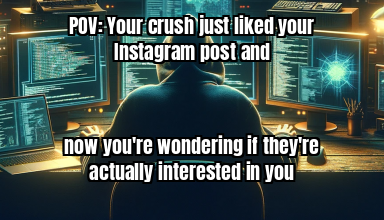

In [ ]:
image